In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [104]:
# =========================
# CARGAR DATA DESDE GITHUB
# =========================
url = "https://raw.githubusercontent.com/AnghieLizzeth22/MasterDS/refs/heads/main/husO104_tri_cumu.csv"

df = pd.read_csv(url)

df = df.rename(columns={df.columns[0]: "date"})
df["date"] = pd.to_datetime(df["date"])

display(df.head())
display(df.describe())

,date,delay0,delay1,delay2,delay3,delay4,delay5,delay6,delay7,delay8,delay9,delay10,delay11,delay12,delay13,delay14,delay15
0,2011-05-07,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1
1,2011-05-08,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2011-05-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2011-05-10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2011-05-11,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,date,delay0,delay1,delay2,delay3,delay4,delay5,delay6,delay7,delay8,delay9,delay10,delay11,delay12,delay13,delay14,delay15
count,59,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2011-06-05 00:00:00,0.067797,0.372881,1.033898,1.898305,3.016949,4.101695,5.118644,5.966102,6.881356,7.677966,8.254237,8.627119,9.067797,9.237288,9.474576,10.677966
min,2011-05-07 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2011-05-21 12:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,2011-06-05 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,3.000000
75%,2011-06-19 12:00:00,0.000000,0.000000,1.000000,2.000000,3.500000,5.500000,6.000000,7.000000,11.000000,13.500000,14.500000,14.500000,15.500000,16.000000,16.000000,16.500000
max,2011-07-04 00:00:00,1.000000,6.000000,11.000000,18.000000,18.000000,26.000000,41.000000,41.000000,41.000000,48.000000,52.000000,53.000000,53.000000,54.000000,56.000000,66.000000
std,NaN,0.253555,0.998245,2.228082,3.442608,4.761525,6.431857,8.414037,9.206381,10.025974,11.154774,11.980722,12.279642,12.791248,13.030917,13.500135,15.584520


In [105]:
# =========================
# TRANSFORMAR A FORMATO LARGO
# =========================
df_long = df.melt(
    id_vars="date",
    var_name="delay",
    value_name="cases"
)

df_long["delay"] = df_long["delay"].str.replace("delay", "").astype(int)
df_long["t"] = df_long["date"].astype("category").cat.codes

print(df_long.head())



        date  delay  cases  t
0 2011-05-07      0      0  0
1 2011-05-08      0      0  1
2 2011-05-09      0      0  2
3 2011-05-10      0      0  3
4 2011-05-11      0      0  4


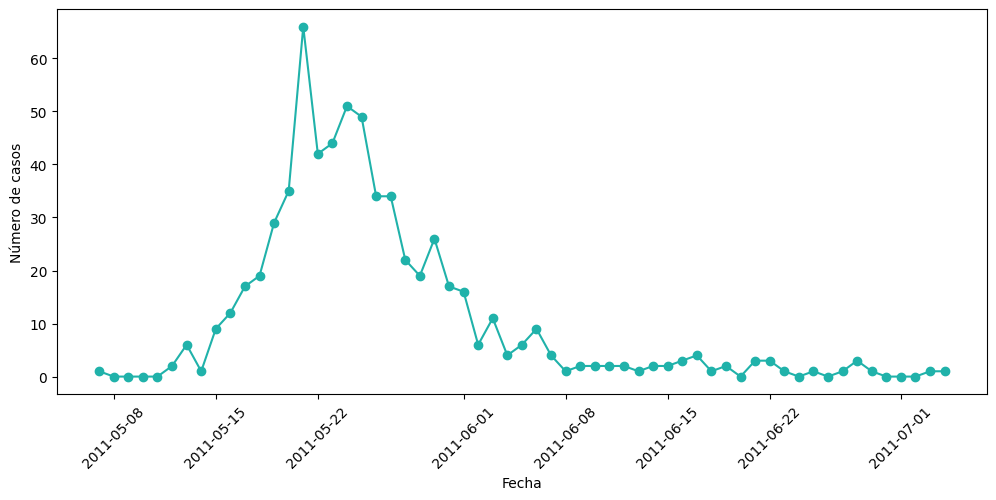

In [106]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["delay15"], marker="o" , color="#20B2AA")

# plt.title("Figura N°01: Evolución de los casos observados (delay máximo)")
plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.xticks(rotation=45)

plt.show()

In [107]:
# =========================
# FILTRAR DELAYS
# =========================
MAX_DELAY_TRAIN = 10
df_train = df_long[df_long["delay"] <= MAX_DELAY_TRAIN]

In [108]:
# =========================
# PREPARAR VARIABLES
# =========================
y = df_long["cases"].values   # datos observados
d = df_long["delay"].values   # retraso
t_index = df_long["t"].values  #tiempo
n_t = df_long["t"].nunique()  # nro de edias

In [116]:
# =========================
# MODELO BAYESIANO
# =========================
with pm.Model() as model:
    lambda_t = pm.Gamma("lambda_t", alpha=2, beta=0.1, shape=n_t)
    phi = pm.Beta("phi", alpha=1, beta=2)

    b = pm.Exponential("b", 1.0)
    p = 1 - (1 - phi) * pm.math.exp(-b * d)
    mu = lambda_t[t_index] * p
    y_obs = pm.Poisson("y_obs", mu=mu, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9)

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


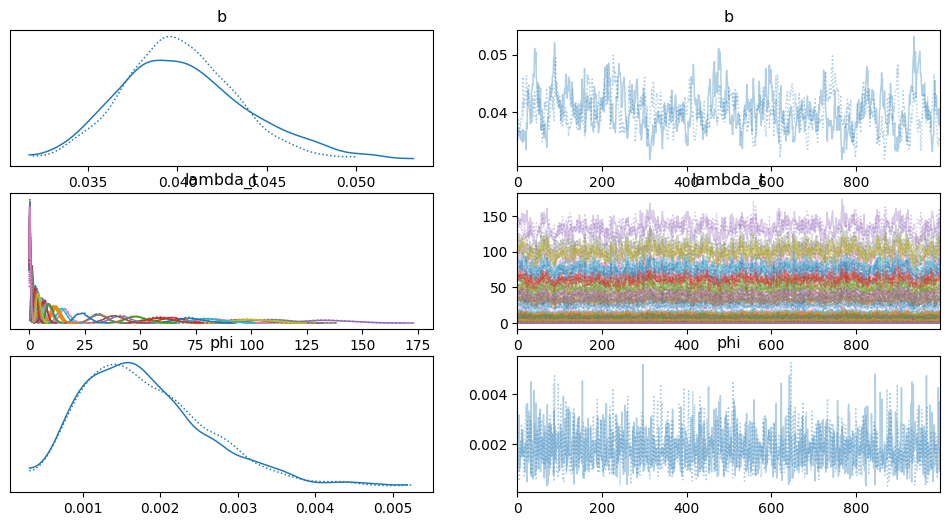

In [117]:
az.plot_trace(trace)
plt.show()

In [118]:
# =========================
# ESTIMACIÓN (NOWCASTING)
# =========================
lambda_est = trace.posterior["lambda_t"].mean(dim=["chain", "draw"]).values

dates_sorted = np.sort(df_long["date"].unique())

df_lambda = pd.DataFrame({
    "date": dates_sorted,
    "estimated_cases": lambda_est
}).sort_values("date")

df_obs = df.set_index("date")["delay15"].sort_index()

df_compare = df_lambda.merge(
    df_obs.reset_index(),
    on="date",
    how="inner"
)

df_compare = df_compare.rename(columns={"delay15": "observed"})

df_compare["difference"] = df_compare["estimated_cases"] - df_compare["observed"]


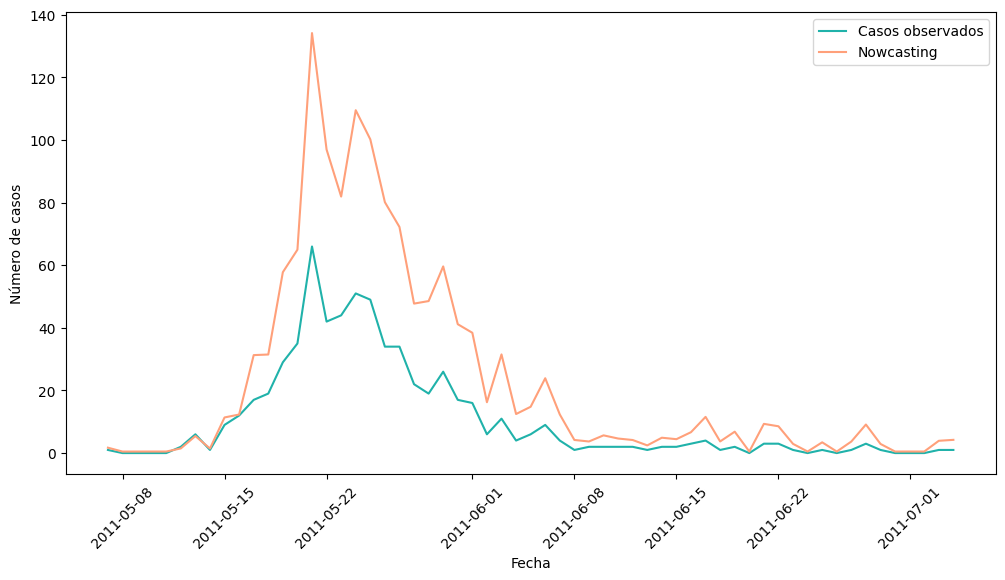

In [125]:
plt.figure(figsize=(12,6))

plt.plot(df_compare["date"], df_compare["observed"],
         label="Casos observados", color="#20B2AA")

plt.plot(df_compare["date"], df_compare["estimated_cases"],
         label="Nowcasting", color="#FFA07A")

# plt.title("Figura N°02: Comparación entre casos observados y estimados")
plt.xlabel("Fecha")
plt.ylabel("Número de casos")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [120]:
mae = mean_absolute_error(df_compare["observed"], df_compare["estimated_cases"])
rmse = np.sqrt(mean_squared_error(df_compare["observed"], df_compare["estimated_cases"]))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 12.364776524936246
RMSE: 20.93865638691057


In [121]:
print(df_compare.head(10))
print("MAE:", mae)

        date  estimated_cases  observed  difference
0 2011-05-07         1.720220         1    0.720220
1 2011-05-08         0.484334         0    0.484334
2 2011-05-09         0.489087         0    0.489087
3 2011-05-10         0.496118         0    0.496118
4 2011-05-11         0.493174         0    0.493174
5 2011-05-12         1.479320         2   -0.520680
6 2011-05-13         5.432864         6   -0.567136
7 2011-05-14         1.463718         1    0.463718
8 2011-05-15        11.381152         9    2.381152
9 2011-05-16        12.313865        12    0.313865
MAE: 12.364776524936246


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5356/1646086786.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("$\lambda_t - Y_{t,D}$")


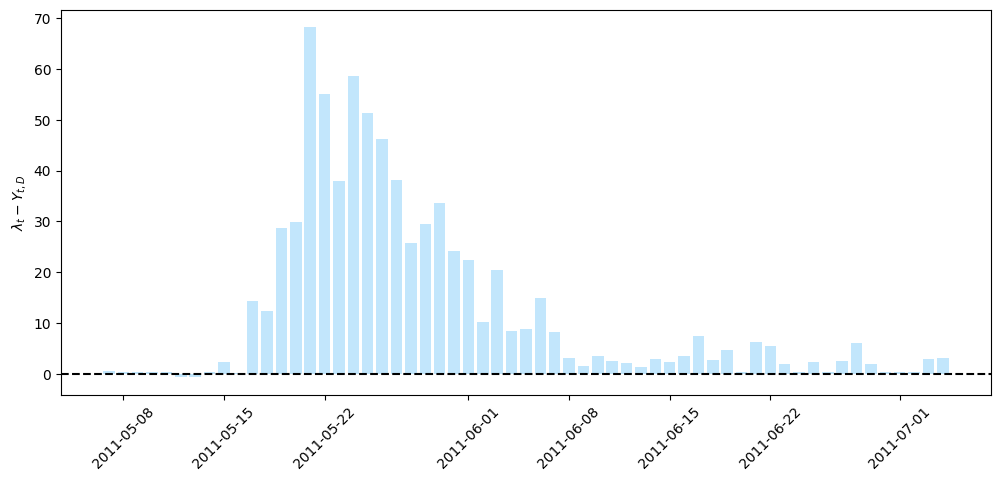

In [128]:
plt.figure(figsize=(12,5))
plt.bar(df_compare["date"], df_compare["difference"], color="#87CEFA", alpha=0.5, label="Casos faltantes")
plt.axhline(0, color="black", linestyle="--")
# plt.title("Figura N°03: Magnitud del Subreporte Estimado")
plt.xticks(rotation=45)
plt.ylabel("$\lambda_t - Y_{t,D}$")
plt.show()